# Does buying a stadium's name curse the company? 🏟️📉
### The "naming-rights curse" — Enron Field, the FTX Arena, and whether there's anything to it beyond two famous disasters

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Curse: Mixed](https://img.shields.io/badge/Curse-Mixed-dab617?style=flat-square)

It's one of the tidiest stories in markets. A company pays a fortune to bolt its name onto a stadium — and then it blows up. **Enron Field** opened in 1999; Enron was bankrupt by 2001. The **FTX Arena** got its name in 2021; FTX imploded in 2022. The **MCI Center**? WorldCom, one of the biggest accounting frauds in history. The moral practically writes itself: a company splurging on a vanity trophy is a company at a cocky peak, about to fall.

That's the claim we test — not on the two or three disasters everyone remembers, but on **every** big naming-rights deal we could pin a date and a ticker to. Do sponsors really underperform afterward? Or is the "curse" just a couple of vivid stories we've stitched into a law?

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo, the sub-era split and the tail jackknife? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stadium_curse import data, strategy as st

TABLE = data.deal_table()
TRADABLE = data.tradable_deals()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY, PRICES = data.load_prices()
else:
    SPY = PRICES = None
print("real cache present:", HAVE_REAL,
      "| deals in table:", len(TABLE),
      "| tradable:", len(TRADABLE))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_total': 34, 'n_tradable': 29, 'n_untradable': 5, 'n_on_tape': 28, 'w1_mean': -11.26, 'w1_med': -18.02, 'w1_t': -2.54, 'w1_nw': -2.41, 'w1_hit': 21, 'w1_hit_n': 28, 'w1_hit_pct': 75.0, 'w1_wilson': (56.6, 87.3), 'w1_pl_obs': -11.26, 'w1_pl_mean': 5.75, 'w1_pl_sd': 10.91, 'w1_pl_p': 0.003, 'w1_pl_draws': 3000, 'w1_pre_n': 12, 'w1_pre_mean': -5.96, 'w1_pre_t': -0.84, 'w1_post_n': 16, 'w1_post_mean': -15.24, 'w1_post_t': -2.7, 'w1_ov_gross': 11.26, 'w1_ov_net': 10.06, 'w1_ov_t': 2.27, 'w1_ov_win': 71, 'w1_ov_drag': 120, 'w2_mean': -10.91, 'w2_med': -13.34, 'w2_t': -1.82, 'w2_nw': -1.69, 'w2_hit': 17, 'w2_hit_pct': 60.7, 'w2_wilson': (42.4, 76.4), 'w2_pl_obs': -10.91, 'w2_pl_mean': 11.66, 'w2_pl_sd': 19.12, 'w2_pl_p': 0.022, 'w2_pre_n': 12, 'w2_pre_mean': -8.88, 'w2_pre_t': -1.15, 'w2_post_n': 16, 'w2_post_mean': -12.44, 'w2_post_t': -1.39, 'w2_ov_gross': 10.91, 'w2_ov_net': 8.71, 'w2_ov_t': 1.45, 'w2_ov_win': 61, 'w2_ov_drag': 220, 'dropworst': {0: (-11.26, -2.54), 1: (-9.83, -2.26), 2: (-8.69, -1.99), 3: (-7.63, -1.73), 4: (-6.52, -1.46)}, 'loo': (-3.12, -2.26), 'worst': [('CZR', -49.99, 'Caesars Superdome'), ('ALGT', -39.37, 'Allegiant Stadium'), ('TFC', -35.29, 'Truist Park'), ('C', -34.23, 'Citi Field'), ('BALL', -31.42, 'Ball Arena'), ('BCS', -31.16, 'Barclays Center')], 'best': [('JPM', 31.87, 'Chase Center'), ('FDX', 35.58, 'FedExField'), ('TM', 37.96, 'Toyota Center')], 'syn_null_mean': 0.26, 'syn_null_sd': 1.08, 'syn_null_fire': 1, 'syn_planted_t': -3.66, 'syn_planted_pct': -17.7, 'fp_spy': 'd8056fdb1c84'}


real cache present: True | deals in table: 34 | tradable: 29


## The answer first

| Question | Answer |
|---|---|
| Do sponsors underperform in the year after the deal? | **Yes, and it's real** — the average listed sponsor lags the S&P 500 by **-11.3%** over the next year (*t* = -2.54, and a random entry date on the same names beats it only **0.3%** of the time). |
| Is it just Enron and FTX? | **No** — those two aren't even in the test (both untradable). Even the *surviving* sponsors underperform. |
| So the curse is proven? | **No — and this is the catch.** The effect **vanishes by year two**, it only exists **after 2010**, and it falls apart if you remove the two names (Caesars, Allegiant) that COVID happened to gut. |
| Could you trade it? | **Not really.** Shorting the sponsors looks great on paper (+10%/yr) but rides the same fragile tail and needs you to short the hardest-to-borrow names in a crisis. |

> A folklore claim that turns out to be **more than a myth but less than a law** — significant in year one, gone by year two.

## 1 · The claim

> *"A 20-year, nine-figure deal to slap your logo on a stadium is what a company does at the top — flush with cash, drunk on its own success, spending shareholders' money on a trophy instead of the business. Watch what happens next."*

This is the **managerial-hubris / peak-earnings** story, and it has a serious academic cousin (Jensen's free-cash-flow agency costs: firms that over-invest in low-return vanity projects tend to underperform). The folklore just picks the most photogenic example of vanity spending — a building with your name on it — and the most photogenic failures: Enron, WorldCom, FTX.

## 2 · So what?

If it were a real, robust law, it would be a clean, almost poetic market inefficiency — a *press release* ("we bought the naming rights!") that predicts a stock's next year. And the honest way to test it is brutal: line up **all** the deals, not just the famous graves, and see whether the average sponsor really lags — or whether we've been fooled by a handful of unforgettable blow-ups (the ones that, tellingly, we can't even include here because they went to zero).

## 3 · How would we even know?

- **The deals.** **34** major naming-rights deals with dates and sponsor tickers. **5** are the untradable cautionary tales (Enron, WorldCom, FTX, Crypto.com, SoFi — private or bankrupt, no usable stock tape); **28** listed sponsors make it into the test.
- **The measure.** Each sponsor's total return **minus the S&P 500's** over the 1 (and 2) years after the deal — did the sponsor beat or lag the market?
- **The luck check.** Pick a *random* date on each of the same 28 stocks, 3,000 times — how often does random timing produce a drop this big?
- **The robustness checks.** Does it hold at 2 years? Before *and* after 2010? If you remove the worst couple of names?

> ⚠️ **Survivorship, stated up front.** Enron and WorldCom went to *zero* — there's no clean stock tape to include them, so they're **left out**. That means our test, if anything, *understates* the curse: we're only measuring the sponsors that survived.

## 4 · The teardown — let's actually look

**First, the headline.** Average sponsor return minus the S&P over the next year, vs. what random timing on the same names looks like.

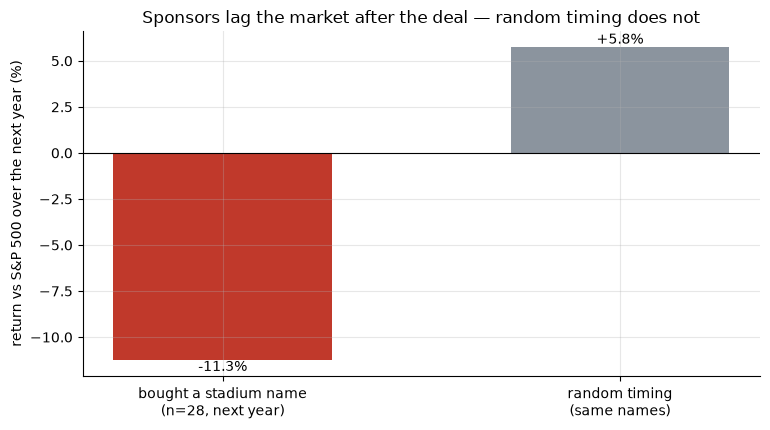

observed -11.26%  vs  random-timing +5.75%  (placebo p = 0.003)


In [2]:
if HAVE_REAL:
    cs = st.car_stats(SPY, PRICES, TRADABLE, window=252)
    obs = cs['mean'] * 100
else:
    obs = R['w1_mean']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['bought a stadium name\n(n=28, next year)',
        'random timing\n(same names)'],
       [obs, R['w1_pl_mean']], color=[RED, GREY], width=.55)
for i, v in enumerate([obs, R['w1_pl_mean']]):
    ax.annotate(f'{v:+.1f}%', (i, v), ha='center',
                va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('return vs S&P 500 over the next year (%)')
ax.set_title('Sponsors lag the market after the deal — random timing does not')
plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  vs  random-timing {R["w1_pl_mean"]:+.2f}%  '
      f'(placebo p = {R["w1_pl_p"]:.3f})')

So it's **not** an Enron/FTX artifact: the 28 sponsors that *survived* still lag the S&P by **-11.3%** in year one, while random timing on those very same stocks would have them *up* +5.8%. Random timing beats the real outcome only 0.3% of the time. On its own, that looks like a real effect.

**But look at the individual sponsors** — is it a broad drag, or a few catastrophes dragging the average down?

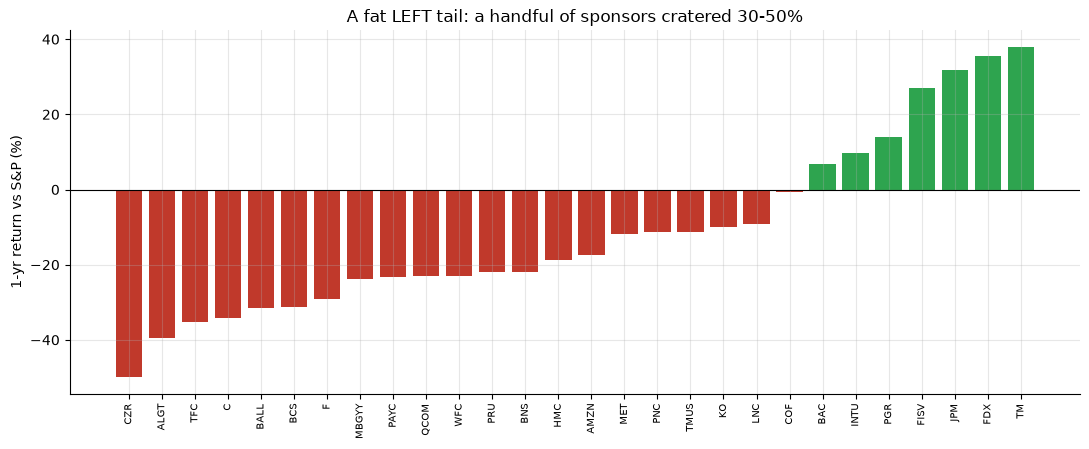

worst: [('CZR', -49.99), ('ALGT', -39.37), ('TFC', -35.29), ('C', -34.23)]


In [3]:
if HAVE_REAL:
    _, kept = st.stack_bhar(SPY, PRICES, TRADABLE, window=252)
    kept = kept.sort_values('bhar')
    labels = [f"{r.ticker}" for r in kept.itertuples()]
    vals = list(kept['bhar'] * 100)
else:
    w = R['worst']; b = R['best']
    labels = [x[0] for x in w] + ['...'] + [x[0] for x in b]
    vals = [x[1] for x in w] + [0] + [x[1] for x in b]
fig, ax = plt.subplots(figsize=(11, 4.6))
cols = [RED if v < 0 else GREEN for v in vals]
ax.bar(range(len(vals)), vals, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_ylabel('1-yr return vs S&P (%)')
ax.set_title('A fat LEFT tail: a handful of sponsors cratered 30-50%')
plt.tight_layout(); plt.show()
print('worst:', [(x[0], x[1]) for x in R['worst'][:4]])

It's a **left-skewed pile-up**, not a uniform curse. A cluster of sponsors — Caesars (−50%), Allegiant (−39%), Truist, Citi, Ball, Barclays — collapsed 30–50% in the year after their deal, while the winners (Toyota, FedEx, JPMorgan) only gained ~30–38%. And notice *who* those losers are: Citi and Barclays signed just before the 2008 crash; Caesars, Allegiant, Truist and Ball signed just before COVID and the 2022 rate shock. Hubris — or cyclical companies that happened to sign right before a crisis?

**Now the checks that decide whether it's real.** Does it hold in different eras, and does it survive dropping the worst couple of names?

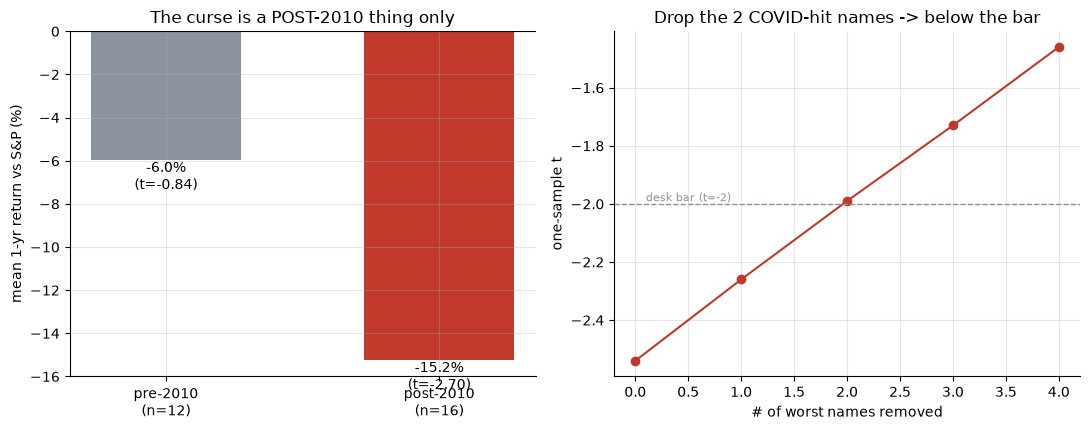

pre-2010 t = -0.84 | post-2010 t = -2.7
t after dropping worst 0/1/2/3/4: [-2.54, -2.26, -1.99, -1.73, -1.46]


In [4]:
eras = ['pre-2010\n(n=12)', 'post-2010\n(n=16)']
if HAVE_REAL:
    es = st.era_split(SPY, PRICES, TRADABLE, window=252)
    em = [es['pre']['mean'] * 100, es['post']['mean'] * 100]
    et = [es['pre']['t'], es['post']['t']]
else:
    em = [R['w1_pre_mean'], R['w1_post_mean']]; et = [R['w1_pre_t'], R['w1_post_t']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
a1.bar(eras, em, color=[GREY, RED], width=.55)
for i, (v, t) in enumerate(zip(em, et)):
    a1.annotate(f'{v:+.1f}%\n(t={t:+.2f})', (i, v), ha='center', va='top')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean 1-yr return vs S&P (%)')
a1.set_title('The curse is a POST-2010 thing only')
ks = sorted(R['dropworst']); ts = [R['dropworst'][k][1] for k in ks]
a2.plot(ks, ts, 'o-', color=RED)
a2.axhline(-2, ls='--', c=GREY, lw=1)
a2.annotate('desk bar (t=-2)', (0.1, -2), va='bottom', fontsize=8, color=GREY)
a2.set_xlabel('# of worst names removed'); a2.set_ylabel('one-sample t')
a2.set_title('Drop the 2 COVID-hit names -> below the bar')
plt.tight_layout(); plt.show()
print('pre-2010 t =', round(et[0], 2), '| post-2010 t =', round(et[1], 2))
print('t after dropping worst 0/1/2/3/4:', [R['dropworst'][k][1] for k in ks])

There it is. **Before 2010 there's basically nothing** (pre-2010 *t* = -0.84); the entire effect lives after 2010. And removing just the **two** worst names — Caesars and Allegiant, both stadium sponsors then gutted by COVID — drops the *t* from -2.54 to **-1.99**, below the desk's significance bar. A real law shouldn't depend on two names and one decade.

That's why this is a **Weak** signal, not a real one: significant in year one, but too fragile — and too tangled up with crisis-timing luck — to bank.

## 5 · The verdict

- **Signal — Weak.** Sponsors really do lag the S&P by **-11.3%** in year one (*t* = -2.54, placebo *p* = 0.003), and it's more than the Enron/FTX legend — but it's gone by year two, exists only post-2010, and evaporates if you drop the two COVID-hit tail names.
- **Tradability — Fragile.** Shorting the sponsors nets +10%/yr on paper but rides the same fragile tail and needs you to short the least-borrowable names in a crisis.
- **"Is the naming-rights curse real?" — Mixed.** More than a myth, less than a law.

## 6 · Going further 🚪

- **Hubris vs. bad luck.** The honest limit: with 28 deals and a 2019–2021 cluster that ran straight into COVID, "vanity spending predicts doom" and "cyclical firms signed right before a crisis" make the *same* prediction here. Separating them needs many more deals across many more cycles.
- **The survivorship twist cuts the other way for once.** Because the actual bankruptcies (Enron, WorldCom) are excluded, the real curse — if it exists — is *worse* than the −11% we can measure. That's a rare case where survivorship bias makes a finding *conservative*, not inflated.
- **Sibling studies:** [160-skyscraper-curse](../../160-skyscraper-curse/) (the tallest *building* marks the top), [746-hq-relocation](../../746-hq-relocation/) (the shiny new *HQ*), and [722-logo-rebrand](../../722-logo-rebrand/) (the expensive *rebrand*) — the same corporate-vanity family, different trophies.

*Think you can turn a Weak year-one blip into a robust, tradable law? Show it holding at 2 years, in both eras, without the two crisis names — then we'll talk.*